In [2]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
plt.rcParams['font.sans-serif'] = ['SimHei']  # 支持中文显示
plt.rcParams['axes.unicode_minus'] = False  # 解决负号显示问题

# 读取数据
data = pd.read_csv('regional_economy_420.csv')

Y = data['Y']


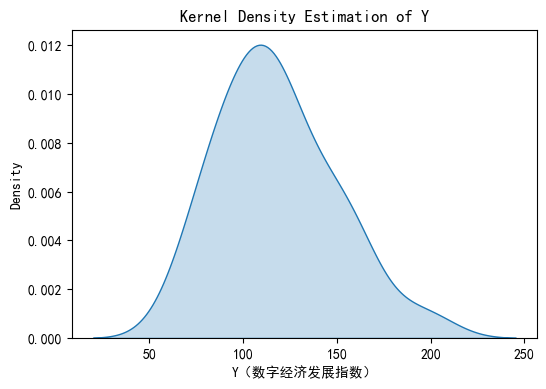

In [3]:
# 绘制核密度估计图
plt.figure(figsize=(6, 4))

# kde=True 表示核密度估计
sns.kdeplot(Y, fill=True)

plt.xlabel('Y（数字经济发展指数）')
plt.ylabel('Density')
plt.title('Kernel Density Estimation of Y')

plt.show()

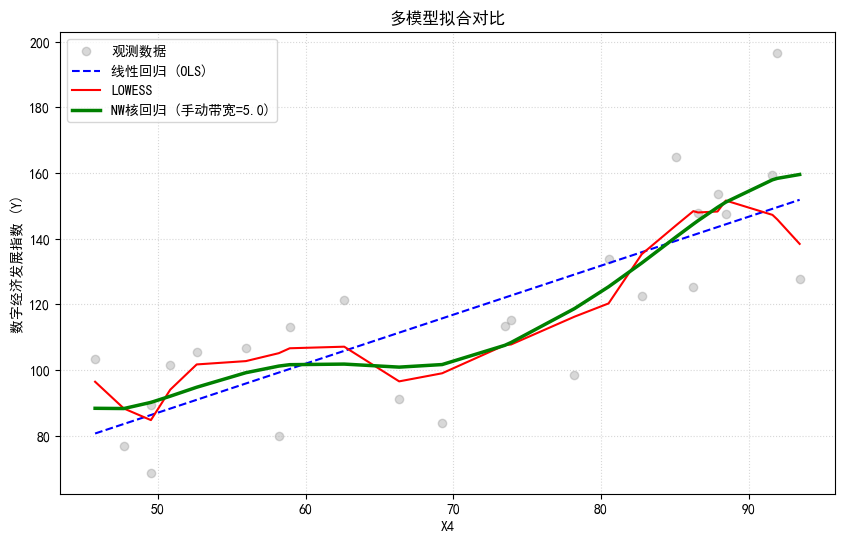

In [16]:
import matplotlib.pyplot as plt
import statsmodels.api as sm
from statsmodels.nonparametric.smoothers_lowess import lowess
from statsmodels.nonparametric.kernel_regression import KernelReg
import numpy as np

# 设置中文字体
plt.rcParams['font.sans-serif'] = ['SimHei']
plt.rcParams['axes.unicode_minus'] = False

# 仅使用 X4 和 Y
X4 = data['X4']
Y = data['Y']
X4_sorted = np.sort(X4)

# =========================
# 1. 线性回归（Y ~ X4）
# =========================
X_lin = sm.add_constant(X4)
lin_model = sm.OLS(Y, X_lin).fit()
Y_lin_pred = lin_model.predict(sm.add_constant(X4_sorted))

# =========================
# 2. LOWESS 非参数拟合
# =========================
lowess_result = lowess(Y, X4, frac=0.25)

# =========================
# 3. Nadaraya-Watson 核回归 (关键修改)
# =========================

manual_bw = [5.0]  
nw_model_manual = KernelReg(endog=Y, exog=X4, var_type='c', bw=manual_bw)
Y_nw_pred_manual, _ = nw_model_manual.fit(X4_sorted)

# =========================
# 4. 绘图对比
# =========================
plt.figure(figsize=(10, 6))

# 原始散点
plt.scatter(X4, Y, alpha=0.3, color='gray', label='观测数据')

# 线性回归 (蓝色虚线)
plt.plot(X4_sorted, Y_lin_pred, color='blue', linestyle='--', label='线性回归 (OLS)')

# LOWESS (红色)
plt.plot(lowess_result[:, 0], lowess_result[:, 1], color='red', linewidth=1.5, label='LOWESS')

# Nadaraya-Watson (绿色粗线 - 手动小带宽)
plt.plot(X4_sorted, Y_nw_pred_manual, color='green', linewidth=2.5, label=f'NW核回归 (手动带宽={manual_bw[0]})')

plt.xlabel('X4')
plt.ylabel('数字经济发展指数 (Y)')
plt.title('多模型拟合对比')
plt.legend()
plt.grid(True, linestyle=':', alpha=0.5)
plt.show()